# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Farhan Ahmad Alvaro
- **Email:** farhanahmadalvaro16@gmail.com
- **ID Dicoding:** MC009D5Y2282

## Menentukan Pertanyaan Bisnis

- Jam berapa penyewaan sepeda paling tinggi dalam sehari?

- Pada bulan apa penyewaan sepeda mencapai puncaknya?

## Import Semua Packages/Library yang Digunakan

In [93]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [94]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Load `days_df`

In [95]:
days_df = pd.read_csv("/content/drive/MyDrive/Bike-sharing-dataset/day.csv")
days_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


### Load `hours_df`


In [96]:
hours_df = pd.read_csv("/content/drive/MyDrive/Bike-sharing-dataset/hour.csv")
hours_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- Mengubah day.csv dan hour.csv menjadi dataframe `days_df` dan `hours_df`
- Menampilkan isi kolom dan baris dataframe menggunakan `.head()`


### Assessing Data

In [97]:
days_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [98]:
hours_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [99]:
days_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


In [100]:
hours_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


In [101]:
print("Jumlah duplikasi: ", days_df.duplicated().sum())
print("Jumlah duplikasi: ", hours_df.duplicated().sum())

Jumlah duplikasi:  0
Jumlah duplikasi:  0


In [102]:
days_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [103]:
hours_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Insight:**
- `.info()` , menampilkan tipe data dan tipe kolom pada `days_df` dan `hours_df`
- `.isna().sum()`, menampilkan informasi terkait jumlah missing values yang terdapat dalam setiap kolom pada dataframe `days_df` dan `hours_df`
- Tidak ada duplikasi pada `days_df` dan `hours_df`
- `.describe()`, menampilkan ringkasan parameter statistik dataframe `days_df` dan `hours_df`

### Cleaning Data

In [104]:
days_df['dteday'] = pd.to_datetime(days_df['dteday'])
days_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [105]:
hours_df['dteday'] = pd.to_datetime(hours_df['dteday'])
hours_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [106]:
# Mapping angka weekday ke nama hari
weekday_map = {
    0: 'Minggu',
    1: 'Senin',
    2: 'Selasa',
    3: 'Rabu',
    4: 'Kamis',
    5: 'Jumat',
    6: 'Sabtu'
}

# Mengelompokkan total penyewaan berdasarkan nama hari
weekday_totals = days_df.groupby('weekday')['cnt'].sum()
weekday_totals.index = weekday_totals.index.map(weekday_map)

print("Total penyewaan sepeda berdasarkan nama hari:")
print(weekday_totals)

Total penyewaan sepeda berdasarkan nama hari:
weekday
Minggu    444027
Senin     455503
Selasa    469109
Rabu      473048
Kamis     485395
Jumat     487790
Sabtu     477807
Name: cnt, dtype: int64


**Insight:**
- Mengubah Dtype object menjadi datetime
- `weekday_map`: Sebuah dictionary yang mengubah angka ke nama hari.
- `weekday_totals.index.map(weekday_map)`: Menerapkan mapping ke indeks hasil `groupby` untuk menggantinya dengan nama hari.

## Exploratory Data Analysis (EDA)

In [107]:
days_df.describe(include="all")

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2012-01-01 00:00:00,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
min,1.000000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2011-07-02 12:00:00,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,2012-01-01 00:00:00,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,2012-07-01 12:00:00,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000
std,211.165812,NaN,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452


In [108]:
hours_df.describe(include="all")

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2012-01-02 04:08:34.552045568,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
min,1.0000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2011-07-04 00:00:00,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,2012-01-02 00:00:00,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,2012-07-02 00:00:00,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000
std,5017.0295,NaN,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599


In [109]:
# Total penyewaan sepeda per jam
hourly_totals = hours_df.groupby('hr')['cnt'].sum()

# Menentukan jam dengan penyewaan tertinggi dan terendah
peak_hour = hourly_totals.idxmax()
peak_hour_rentals = hourly_totals.max()
lowest_hour = hourly_totals.idxmin()
lowest_hour_rentals = hourly_totals.min()

print("Total penyewaan sepeda berdasarkan jam:")
print(hourly_totals)
print(f"Jam dengan penyewaan tertinggi: {peak_hour} dengan {peak_hour_rentals} penyewaan")
print(f"Jam dengan penyewaan terendah: {lowest_hour} dengan {lowest_hour_rentals} penyewaan")

Total penyewaan sepeda berdasarkan jam:
hr
0      39130
1      24164
2      16352
3       8174
4       4428
5      14261
6      55132
7     154171
8     261001
9     159438
10    126257
11    151320
12    184414
13    184919
14    175652
15    183149
16    227748
17    336860
18    309772
19    226789
20    164550
21    125445
22     95612
23     63941
Name: cnt, dtype: int64
Jam dengan penyewaan tertinggi: 17 dengan 336860 penyewaan
Jam dengan penyewaan terendah: 4 dengan 4428 penyewaan


In [110]:
# Total penyewaan sepeda per bulan
monthly_totals = days_df.groupby('mnth')['cnt'].sum()

# Menentukan bulan dengan penyewaan tertinggi dan terendah
peak_month = monthly_totals.idxmax()
peak_rentals = monthly_totals.max()
lowest_month = monthly_totals.idxmin()
lowest_rentals = monthly_totals.min()

print("Total penyewaan sepeda berdasarkan bulan:")
print(monthly_totals)
print(f"Bulan dengan penyewaan tertinggi: {peak_month} dengan {peak_rentals} penyewaan")
print(f"Bulan dengan penyewaan terendah: {lowest_month} dengan {lowest_rentals} penyewaan")

Total penyewaan sepeda berdasarkan bulan:
mnth
1     134933
2     151352
3     228920
4     269094
5     331686
6     346342
7     344948
8     351194
9     345991
10    322352
11    254831
12    211036
Name: cnt, dtype: int64
Bulan dengan penyewaan tertinggi: 8 dengan 351194 penyewaan
Bulan dengan penyewaan terendah: 1 dengan 134933 penyewaan


In [111]:
# Pendekatan 1: Manual Grouping Berdasarkan Waktu Penggunaan
def waktu_kelompok(jam):
    if 5 <= jam <= 9:
        return 'Pagi'
    elif 10 <= jam <= 15:
        return 'Siang'
    elif 16 <= jam <= 20:
        return 'Sore/Malam'
    else:
        return 'Larut Malam'

hours_df['waktu_kelompok'] = hours_df['hr'].apply(waktu_kelompok)

print(hours_df[['hr', 'waktu_kelompok']].head())


   hr waktu_kelompok
0   0    Larut Malam
1   1    Larut Malam
2   2    Larut Malam
3   3    Larut Malam
4   4    Larut Malam


In [112]:
waktu_rentals = hours_df.groupby('waktu_kelompok')['cnt'].sum()
print(waktu_rentals)


waktu_kelompok
Larut Malam     377246
Pagi            644003
Siang          1005711
Sore/Malam     1265719
Name: cnt, dtype: int64


In [113]:
#Pendekatan 2: Manual Grouping Berdasarkan Frekuensi Penyewaan
def penyewaan_kelompok(jumlah):
    if jumlah < 500:
        return 'Rendah'
    elif 500 <= jumlah <= 2000:
        return 'Sedang'
    else:
        return 'Tinggi'

days_df['kelompok_penyewaan'] = days_df['cnt'].apply(penyewaan_kelompok)

print(days_df[['cnt', 'kelompok_penyewaan']].head())


    cnt kelompok_penyewaan
0   985             Sedang
1   801             Sedang
2  1349             Sedang
3  1562             Sedang
4  1600             Sedang


In [114]:
#Pendekatan 3: Manual Grouping Berdasarkan Cuaca
cuaca_grup = days_df.groupby('weathersit')['cnt'].sum()
print(cuaca_grup)

weathersit
1    2257952
2     996858
3      37869
Name: cnt, dtype: int64


**Insight:**

- Total penyewaan sepeda berdasarkan weekday
- Total penyewaan sepeda berdasarkan jam

## Visualization & Explanatory Analysis

Pertanyaan 1:

In [119]:
# Total penyewaan per jam
hourly_totals = hours_df.groupby('hr')['cnt'].sum()

# Menemukan jam dengan penyewaan tertinggi
peak_hour = hourly_totals.idxmax()
peak_rentals = hourly_totals.max()
print(f"Penyewaan sepeda tertinggi terjadi pada jam {peak_hour} dengan total {peak_rentals} penyewaan.")

Penyewaan sepeda tertinggi terjadi pada jam 17 dengan total 336860 penyewaan.


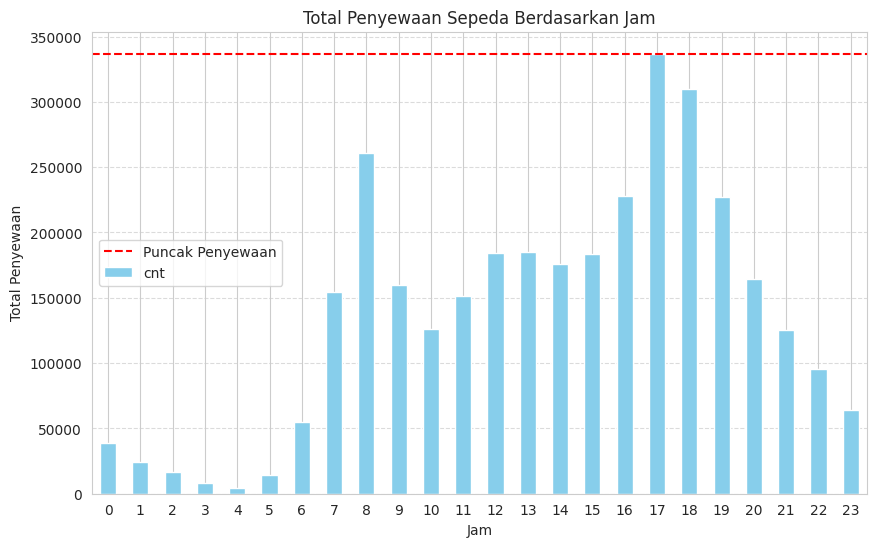

In [120]:
# Visualisasi dalam bar chart
hourly_totals.plot(kind='bar', figsize=(10, 6), color='skyblue')
plt.title('Total Penyewaan Sepeda Berdasarkan Jam')
plt.xlabel('Jam')
plt.ylabel('Total Penyewaan')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.axhline(y=hourly_totals.max(), color='red', linestyle='--', label='Puncak Penyewaan')
plt.legend()

### Pertanyaan 2:

In [117]:
# Total penyewaan per bulan
monthly_totals = days_df.groupby('mnth')['cnt'].sum()

# Menemukan bulan dengan penyewaan tertinggi
peak_month = monthly_totals.idxmax()
peak_month_rentals = monthly_totals.max()

# Cetak hasil
print(f"Penyewaan sepeda tertinggi terjadi pada bulan {peak_month} dengan total {peak_month_rentals} penyewaan.")

Penyewaan sepeda tertinggi terjadi pada bulan 8 dengan total 351194 penyewaan.


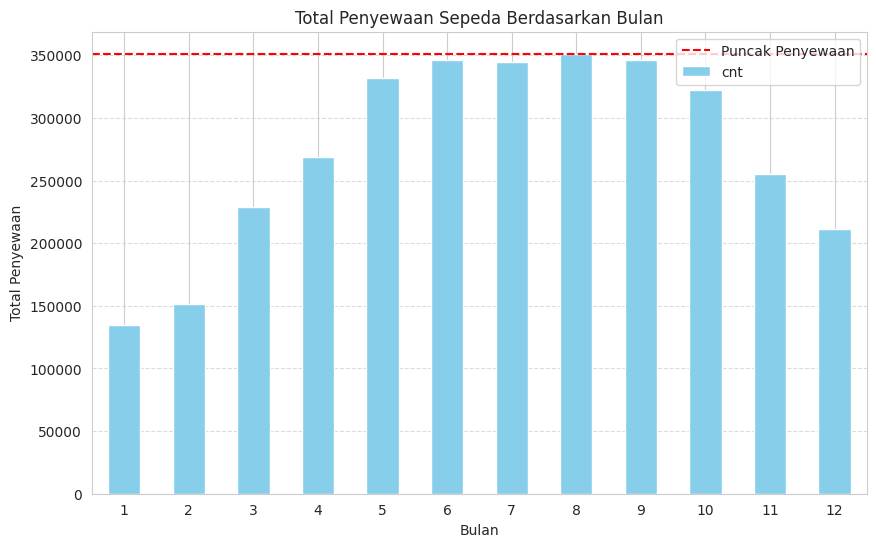

In [118]:
# Visualisasi dalam bar chart
monthly_totals.plot(kind='bar', figsize=(10, 6), color='skyblue')
plt.title('Total Penyewaan Sepeda Berdasarkan Bulan')
plt.xlabel('Bulan')
plt.ylabel('Total Penyewaan')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.axhline(y=monthly_totals.max(), color='red', linestyle='--', label='Puncak Penyewaan')
plt.legend()
plt.show()

**Insight:**
- Jam penyewaan sepeda paling tinggi dalam sehari yaitu pada jam 17.00 dengan 336860 penyewaan.
- Bulan penyewaan sepeda mencapai puncaknya pada bulan Agustus dengan 351194 penyewaan.

## Analisis Lanjutan (Opsional)

## Conclusion

Conclution pertanyaan 1
- Puncak Penyewaan Berdasarkan Jam
- Penyewaan sepeda tertinggi terjadi pada pukul 17:00 (jam 5 sore), dengan jumlah penyewaan mencapai sekitar 336860 penyewaan.
- Penyewaan sepeda terendah terjadi pada pukul 04:00 (jam 4 pagi), dengan jumlah penyewaan mencapai sekitar 4428 penyewaan.
- Hal ini dapat dikaitkan dengan jam sibuk pekerja pulang kantor pada sore hari dan waktu istirahat dini hari.

Conclution pertanyaan 2
- Puncak Penyewaan Berdasarkan Bulan
- Penyewaan sepeda tertinggi terjadi pada bulan Agustus dengan 351194 penyewaan
- Penyewaan sepeda terendah terjadi pada bulan Januari dengan dengan 134933 penyewaan
- Faktor cuaca, liburan musim panas, dan aktivitas luar ruangan yang lebih populer pada bulan Juni kemungkinan menjadi penyebab lonjakan ini.